In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
import math

import os
from glob import glob
import json
import pandas as pd

In [2]:
# Experiment 2
colors = [['#7f2704', '#a50f15', '#de2d26', '#fb6a4a', '#ff005d', '#fcbba1'], 
          ['#000000', '#464b52', '#3d6085', '#3f7eb5', '#3ca5e8', '#79e8ff']]


def preprocess(path,  ):
    # preprocess the files with the results and extract plotting information
    num_ratios = 6
    throughputs = np.genfromtxt(path, delimiter = ',')
    
    # Compute frontier
    frontier_idx = [];
    drop = 0;
    for i in range(0, len(throughputs)):
        for j in range(0, len(throughputs)):
            if((i != j) and (throughputs[i][0] <= throughputs[j][0]) and (throughputs[i][1] <= throughputs[j][1])):
                drop = 1;
        if(drop == 0):
            frontier_idx.append(i)
        else:
            drop = 0;
    frontier_len = len(frontier_idx)
    frontier = np.empty([2, frontier_len])
    for i in range(0, frontier_len):
        frontier[0][i] = throughputs[frontier_idx[i]][0]
        frontier[1][i] = throughputs[frontier_idx[i]][1]
    idx = np.argsort(frontier[0])
    
    # Vertical Lines - Fixed T
    district_tc = int(len(throughputs)/num_ratios)  # number of different T clients 
    district_ac = num_ratios  # number of different A clients
    tt_v = np.empty([district_tc, district_ac])
    ta_v = np.empty([district_tc, district_ac])
    for i in range(0, district_tc):
        for j in range(0, district_ac):
            tt_v[i][j] = throughputs[i* district_ac + j][0]
            ta_v[i][j] = throughputs[i* district_ac + j][1]
            
    # Horizontal Lines - Fixed A
    district_tc = int(len(throughputs)/num_ratios)  # number of different T clients 
    district_ac = num_ratios  # number of different A clients
    ta_h = np.empty([district_ac, district_tc])
    tt_h = np.empty([district_ac, district_tc])
    for i in range(0, district_ac):
        for j in range(0, district_tc):
            tt_h[i][j] = throughputs[j* district_ac + i][0]
            ta_h[i][j] = throughputs[j* district_ac + i][1]
            
    return tt_v, ta_v, tt_h, ta_h, district_tc, frontier, idx

def frontier_plot_basic(x, idx, plt, hatch=True, color='green', lw=6.0, label=''):
    plt.plot(x[0][idx], x[1][idx], '-', c=color, linewidth=lw, label=label, zorder=2)
    x_sorted = x[0][idx]
    y_sorted = x[1][idx]
    
    max_x = x_sorted[-1]
    plt.plot([max_x, max_x], [y_sorted[-1], 0], color, linewidth=lw, zorder=2)
    max_y = y_sorted[0]
    plt.plot([x_sorted[0], 0], [max_y, max_y], color, linewidth=lw, zorder=2)

    if hatch:
        plt.fill_between(x[0][idx], x[1][idx], color='grey', hatch='//', alpha=0.08,  label='AUC') 
        plt.grid(color='#CCCCCC', linestyle='--', linewidth=0.8, zorder=1)

def maxTT(x, i):
    maxTT = x[0][i].max()
    return maxTT

def maxAT(x, i):
    maxAT = x[1][i].max()
    return maxAT

def proportional_line(frontier, idx, plt):
    proportional = [[0, maxTT(frontier, idx)],[maxAT(frontier, idx), 0]]
    plt.plot(proportional[0], proportional[1], '--', c='#084594', linewidth=3, label='Proportional line', zorder=1)

def bounding_box(frontier, idx, plt): 
    b1 = [[0, maxTT(frontier, idx)],[maxAT(frontier, idx), maxAT(frontier, idx)]]
    b2 = [[maxTT(frontier, idx), maxTT(frontier, idx)],[0, maxAT(frontier, idx)]]
    plt.plot(b1[0], b1[1], '--', c='#cb181d', linewidth=3, label='Bounding box')
    plt.plot(b2[0], b2[1], '--', c='#cb181d', linewidth=3)

In [3]:
clients = [['$TC=0$', '$TC=0.1*τ_{max}$', '$TC=0.2*τ_{max}$', '$TC=0.5*τ_{max}$', '$TC=0.8*τ_{max}$', '$TC=τ_{max}$'], 
['$AC=0$', '$AC=0.1*α_{max}$', '$AC=0.2*α_{max}$', '$AC=0.5*α_{max}$', '$AC=0.8*α_{max}$', '$AC=α_{max}$']]

yaxes_size =30
xaxes_size =30
c = 30
label_size = 38
legend_size = 28
sub_label_size=30

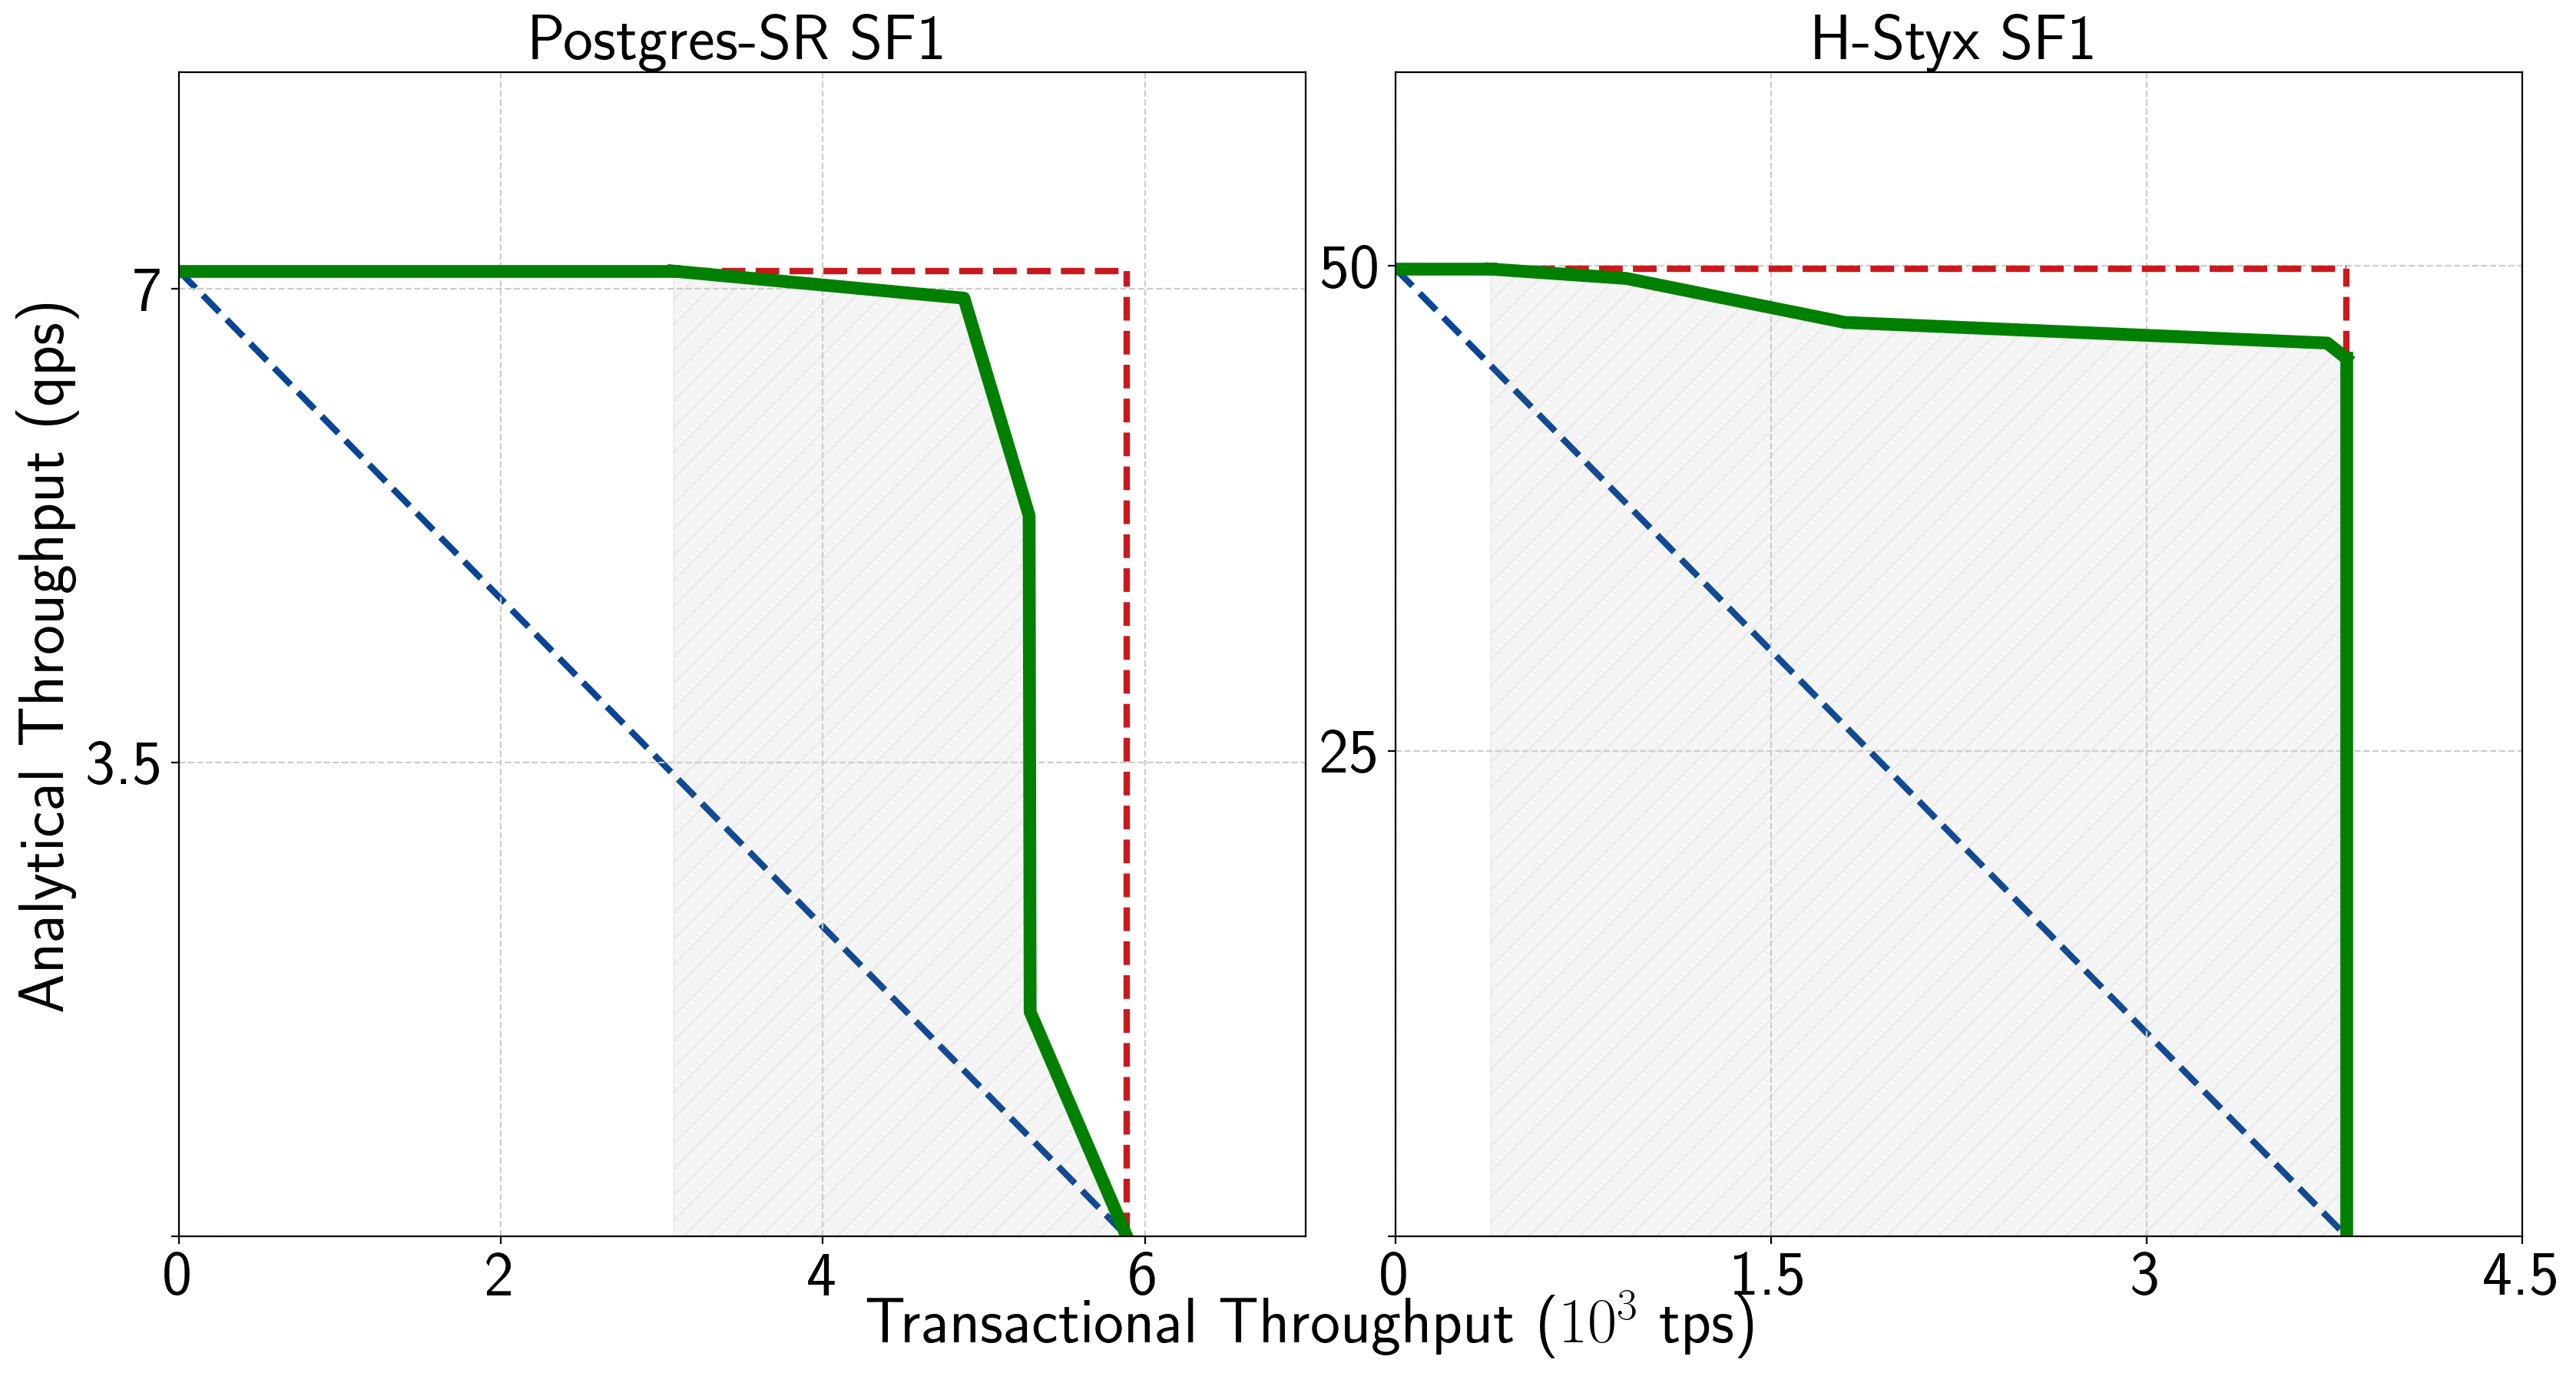

In [8]:
cm = 1/2.54
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(50*cm, 25*cm))
plt.subplots_adjust(wspace=0.08)
plt.rcParams['figure.dpi'] = 200
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['text.usetex'] = True

f.text(0.5, 0.04, 'Transactional Throughput ($10^3$ tps)', ha='center', fontsize=30)

# ------ SF1 postgres-------
path = "postgres/"

tt_v, ta_v, tt_h, ta_h, district_tc, frontier, idx  = preprocess(path+'frontier-SF1.csv')
ax1.axis([0, 7000, 0, 8.6])

x = [0, 2000, 4000,  6000]
xticks = ['0', '2', '4', '6']
y = [0, 3.5, 7]
yticks = ['', '3.5', '7']

ax1.set_xticks(x, minor=False)
ax1.set_xticklabels(xticks, rotation=0, fontsize=xaxes_size)

ax1.set_yticks(y, minor=False)
ax1.set_yticklabels(yticks, rotation=0, fontsize=yaxes_size)

ax1.set_title('Postgres-SR SF1', fontsize=sub_label_size)
proportional_line(frontier, idx, ax1)
bounding_box(frontier, idx, ax1)
frontier_plot_basic(frontier, idx, ax1)


# ------ SF10 ------
path = "styx/"
tt_v, ta_v, tt_h, ta_h, district_tc, frontier, idx  = preprocess(path+'frontier-SF1.csv')
ax2.axis([0, 450, 0, 60])

x = [0, 1500, 3000,  4500]
xticks = ['0', '1.5', '3', '4.5']
y = [0, 25, 50]
yticks = ['', '25', '50']

ax2.set_xticks(x, minor=False)
ax2.set_xticklabels(xticks, rotation=0, fontsize=xaxes_size)

ax2.set_yticks(y, minor=False)
ax2.set_yticklabels(yticks, rotation=0, fontsize=yaxes_size)

ax1.set_ylabel('Analytical Throughput (qps)', fontsize=30)

ax2.set_title('H-Styx SF1', fontsize=sub_label_size)
proportional_line(frontier, idx, ax2)
bounding_box(frontier, idx, ax2)
frontier_plot_basic(frontier, idx, ax2)

f.savefig('sf1-frontier-plot.png', bbox_inches='tight')

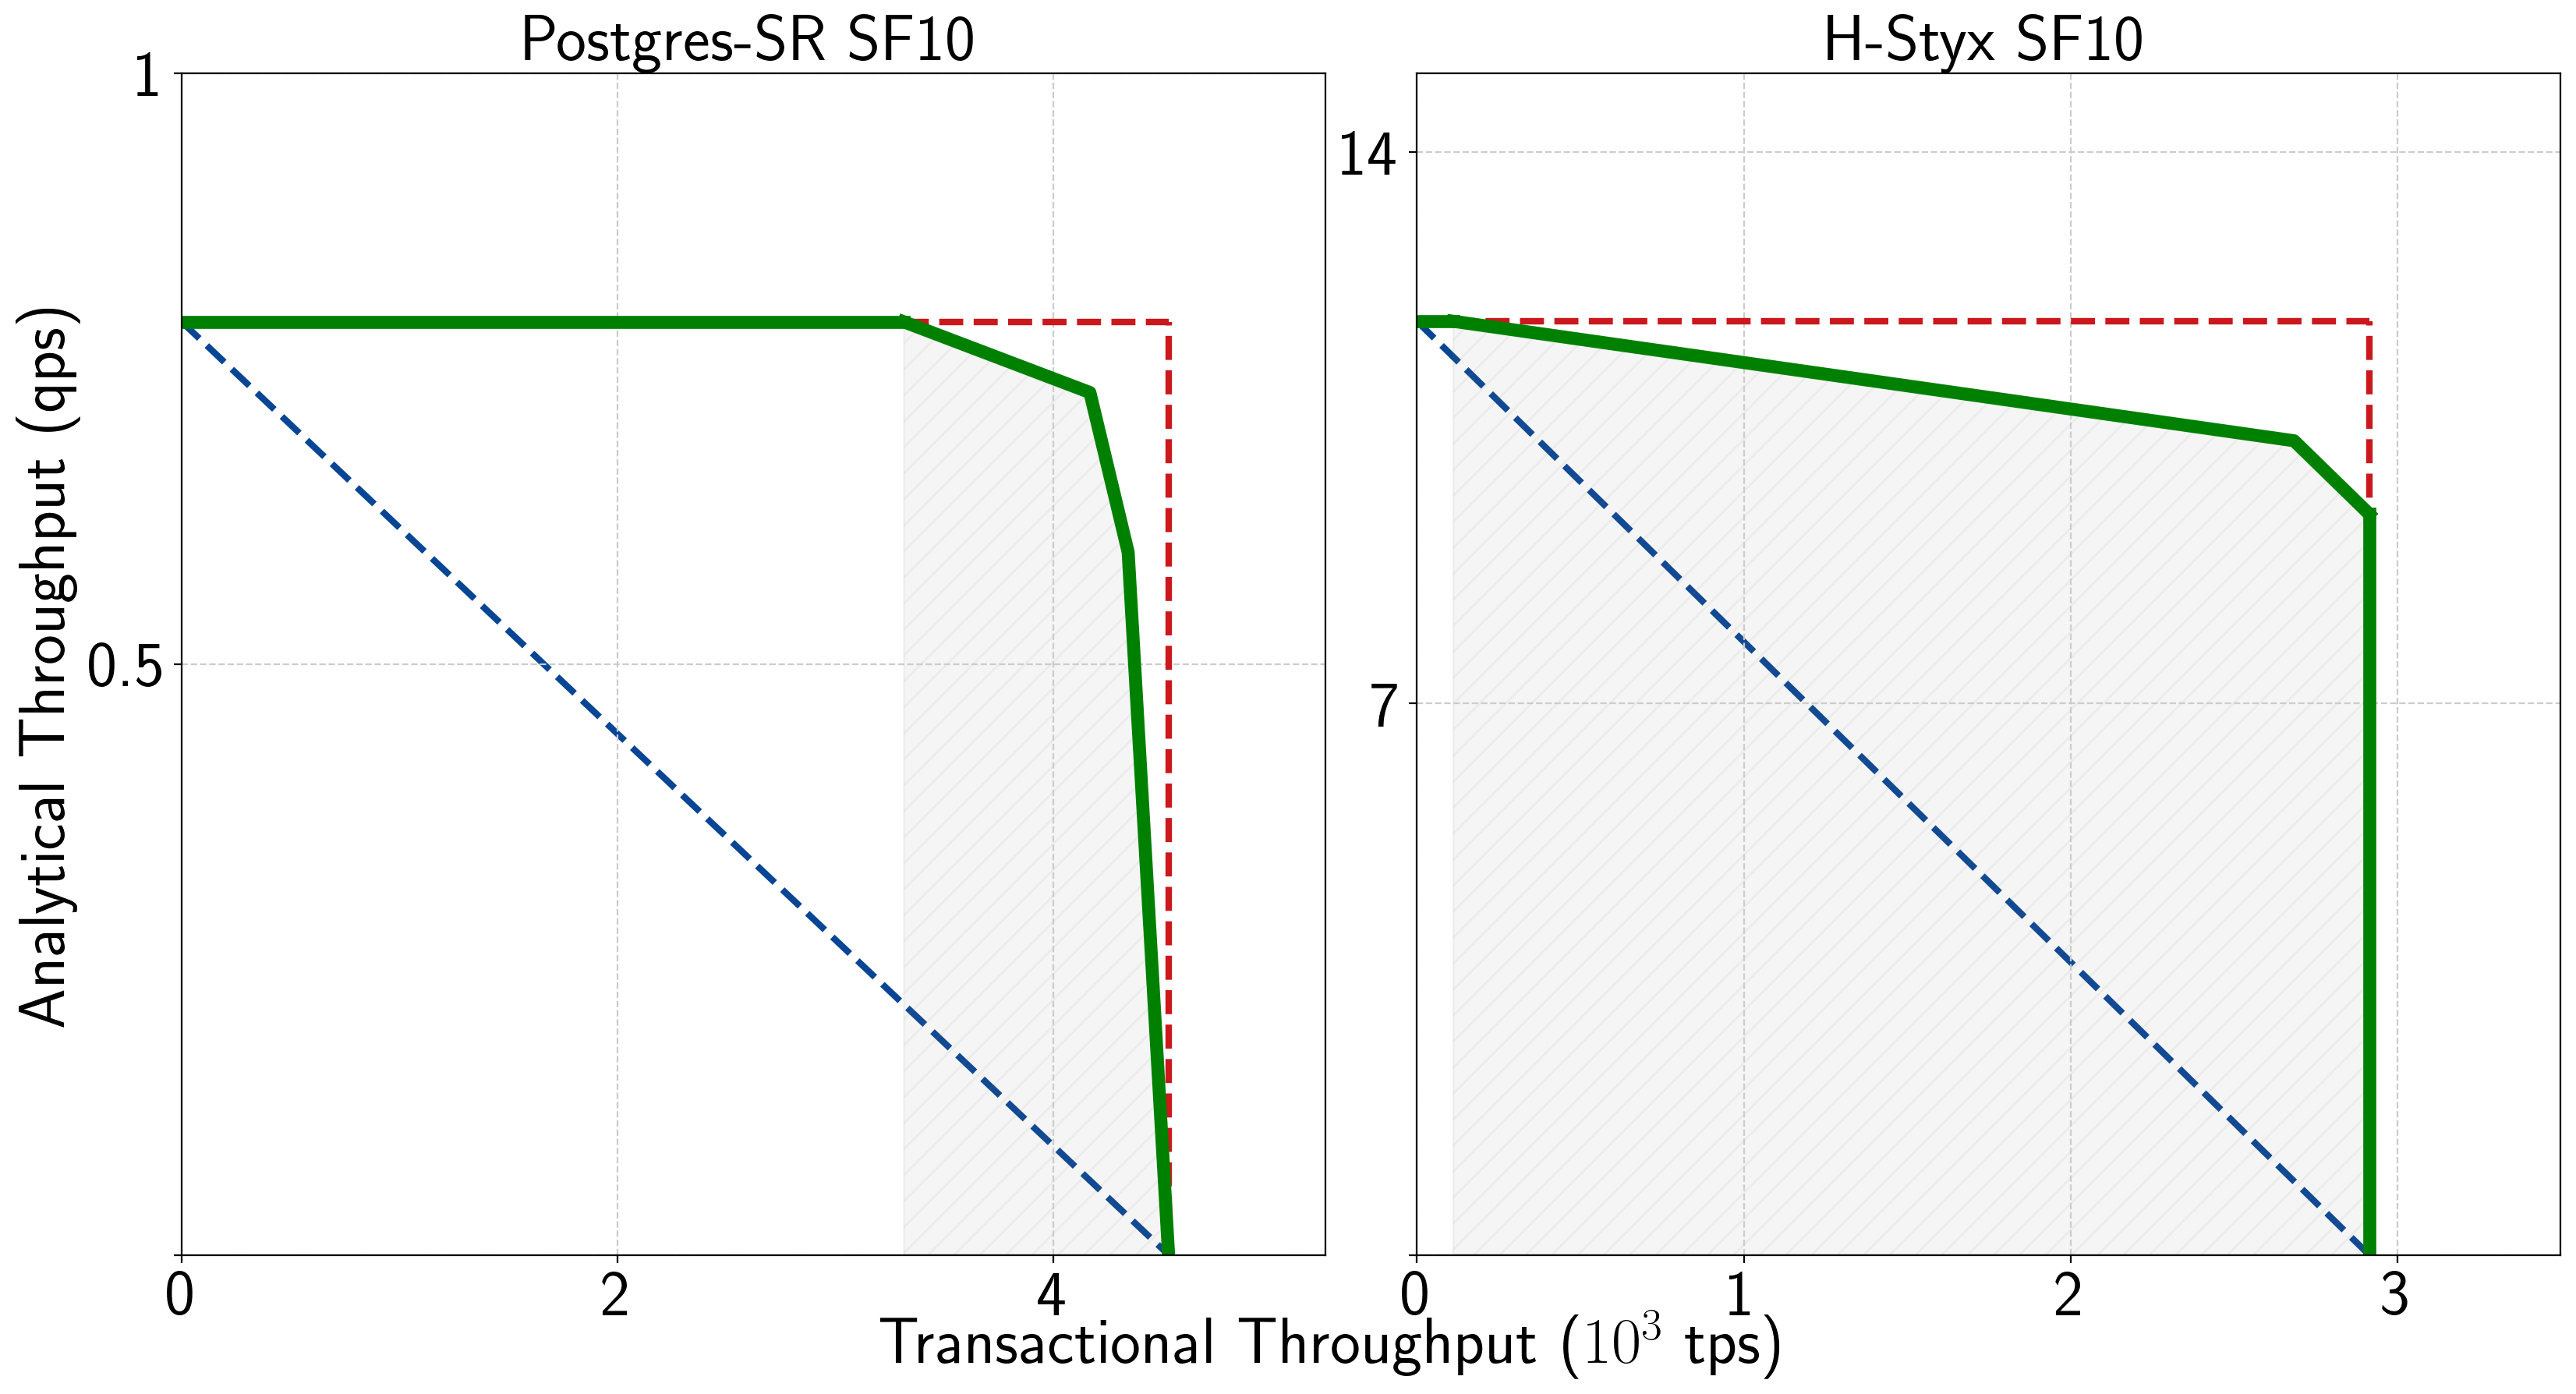

In [7]:
cm = 1/2.54
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(50*cm, 25*cm))
plt.subplots_adjust(wspace=0.08)
plt.rcParams['figure.dpi'] = 200
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['text.usetex'] = True

f.text(0.5, 0.04, 'Transactional Throughput ($10^3$ tps)', ha='center', fontsize=30)

# ------ SF1 -------
path = "postgres/"
tt_v, ta_v, tt_h, ta_h, district_tc, frontier, idx  = preprocess(path+'frontier-SF10.csv')
ax1.axis([0, 5250, 0, 1])

x = [0, 2000, 4000]
xticks = ['0', '2', '4']
y = [0, 0.5, 1]
yticks = ['', '0.5', '1']

ax1.set_xticks(x, minor=False)
ax1.set_xticklabels(xticks, rotation=0, fontsize=xaxes_size)

ax1.set_yticks(y, minor=False)
ax1.set_yticklabels(yticks, rotation=0, fontsize=yaxes_size)

ax1.set_title('Postgres-SR SF10', fontsize=sub_label_size)
proportional_line(frontier, idx, ax1)
bounding_box(frontier, idx, ax1)
frontier_plot_basic(frontier, idx, ax1)

# ------ SF10 ------
path = "styx/"
tt_v, ta_v, tt_h, ta_h, district_tc, frontier, idx  = preprocess(path+'frontier-SF10.csv')
ax2.axis([0, 3500, 0, 15])

x = [0, 1000, 2000, 3000]
xticks = ['0', '1', '2', '3']
y = [0, 7, 14]
yticks = ['',  '7',  '14']

ax2.set_xticks(x, minor=False)
ax2.set_xticklabels(xticks, rotation=0, fontsize=xaxes_size)

ax2.set_yticks(y, minor=False)
ax2.set_yticklabels(yticks, rotation=0, fontsize=yaxes_size)

ax1.set_ylabel('Analytical Throughput (qps)', fontsize=30)

ax2.set_title('H-Styx SF10', fontsize=sub_label_size)
proportional_line(frontier, idx, ax2)
bounding_box(frontier, idx, ax2)
frontier_plot_basic(frontier, idx, ax2)
f.savefig('sf10-frontier-plot.png', bbox_inches='tight')

In [6]:
# f, ax1 = plt.subplots(figsize=(60*cm, 20*cm))
# # plt.rcParams["figure.figsize"] = [7.5, 3.5]
# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['savefig.dpi'] = 200
# plt.rcParams['text.usetex'] = True

# ax1.axis([0, 5000, 0, 13])
# x = [0, 1000, 2000, 3000, 4000, 5000]
# xticks = ['0', '1', '2', '3', '4', '5']
# ax1.set_xticks(x)
# ax1.set_xticklabels(xticks, fontsize=20)
# y = [0, 2, 4, 6, 8, 10, 12]
# yticks = ['', '2', '4', '6', '8', '10', '12']
# ax1.set_yticks(y, minor=False)
# ax1.set_yticklabels(yticks, fontsize=20)

# path = "postgres/"
# tt_v, ta_v, tt_h, ta_h, district_tc, frontier1, idx1  = preprocess(path+'frontier-SF10.csv')

# path = "styx/"
# tt_v, ta_v, tt_h, ta_h, district_tc, frontier2, idx2  = preprocess(path+'frontier-SF10.csv')

# frontier_plot_basic(frontier1, idx1, ax1, lw=4.0, label='PostgreSQL-SR', color='cyan', hatch=False)
# frontier_plot_basic(frontier2, idx2, ax1, lw=4.0, label='H-Styx', color='darkorange', hatch=False)

# ax1.set_xlabel('Transactional Throughput ($10^3$ tps)', fontsize=30)
# ax1.set_ylabel('Analytical Throughput (qps)', fontsize=30)
# plt.rc('grid', linestyle="--", color='#CCCCCC')
# plt.legend(loc="upper right", fontsize=30)
# plt.grid()
# f.savefig('sf10-comparison-plot.png', bbox_inches='tight')
# plt.show()

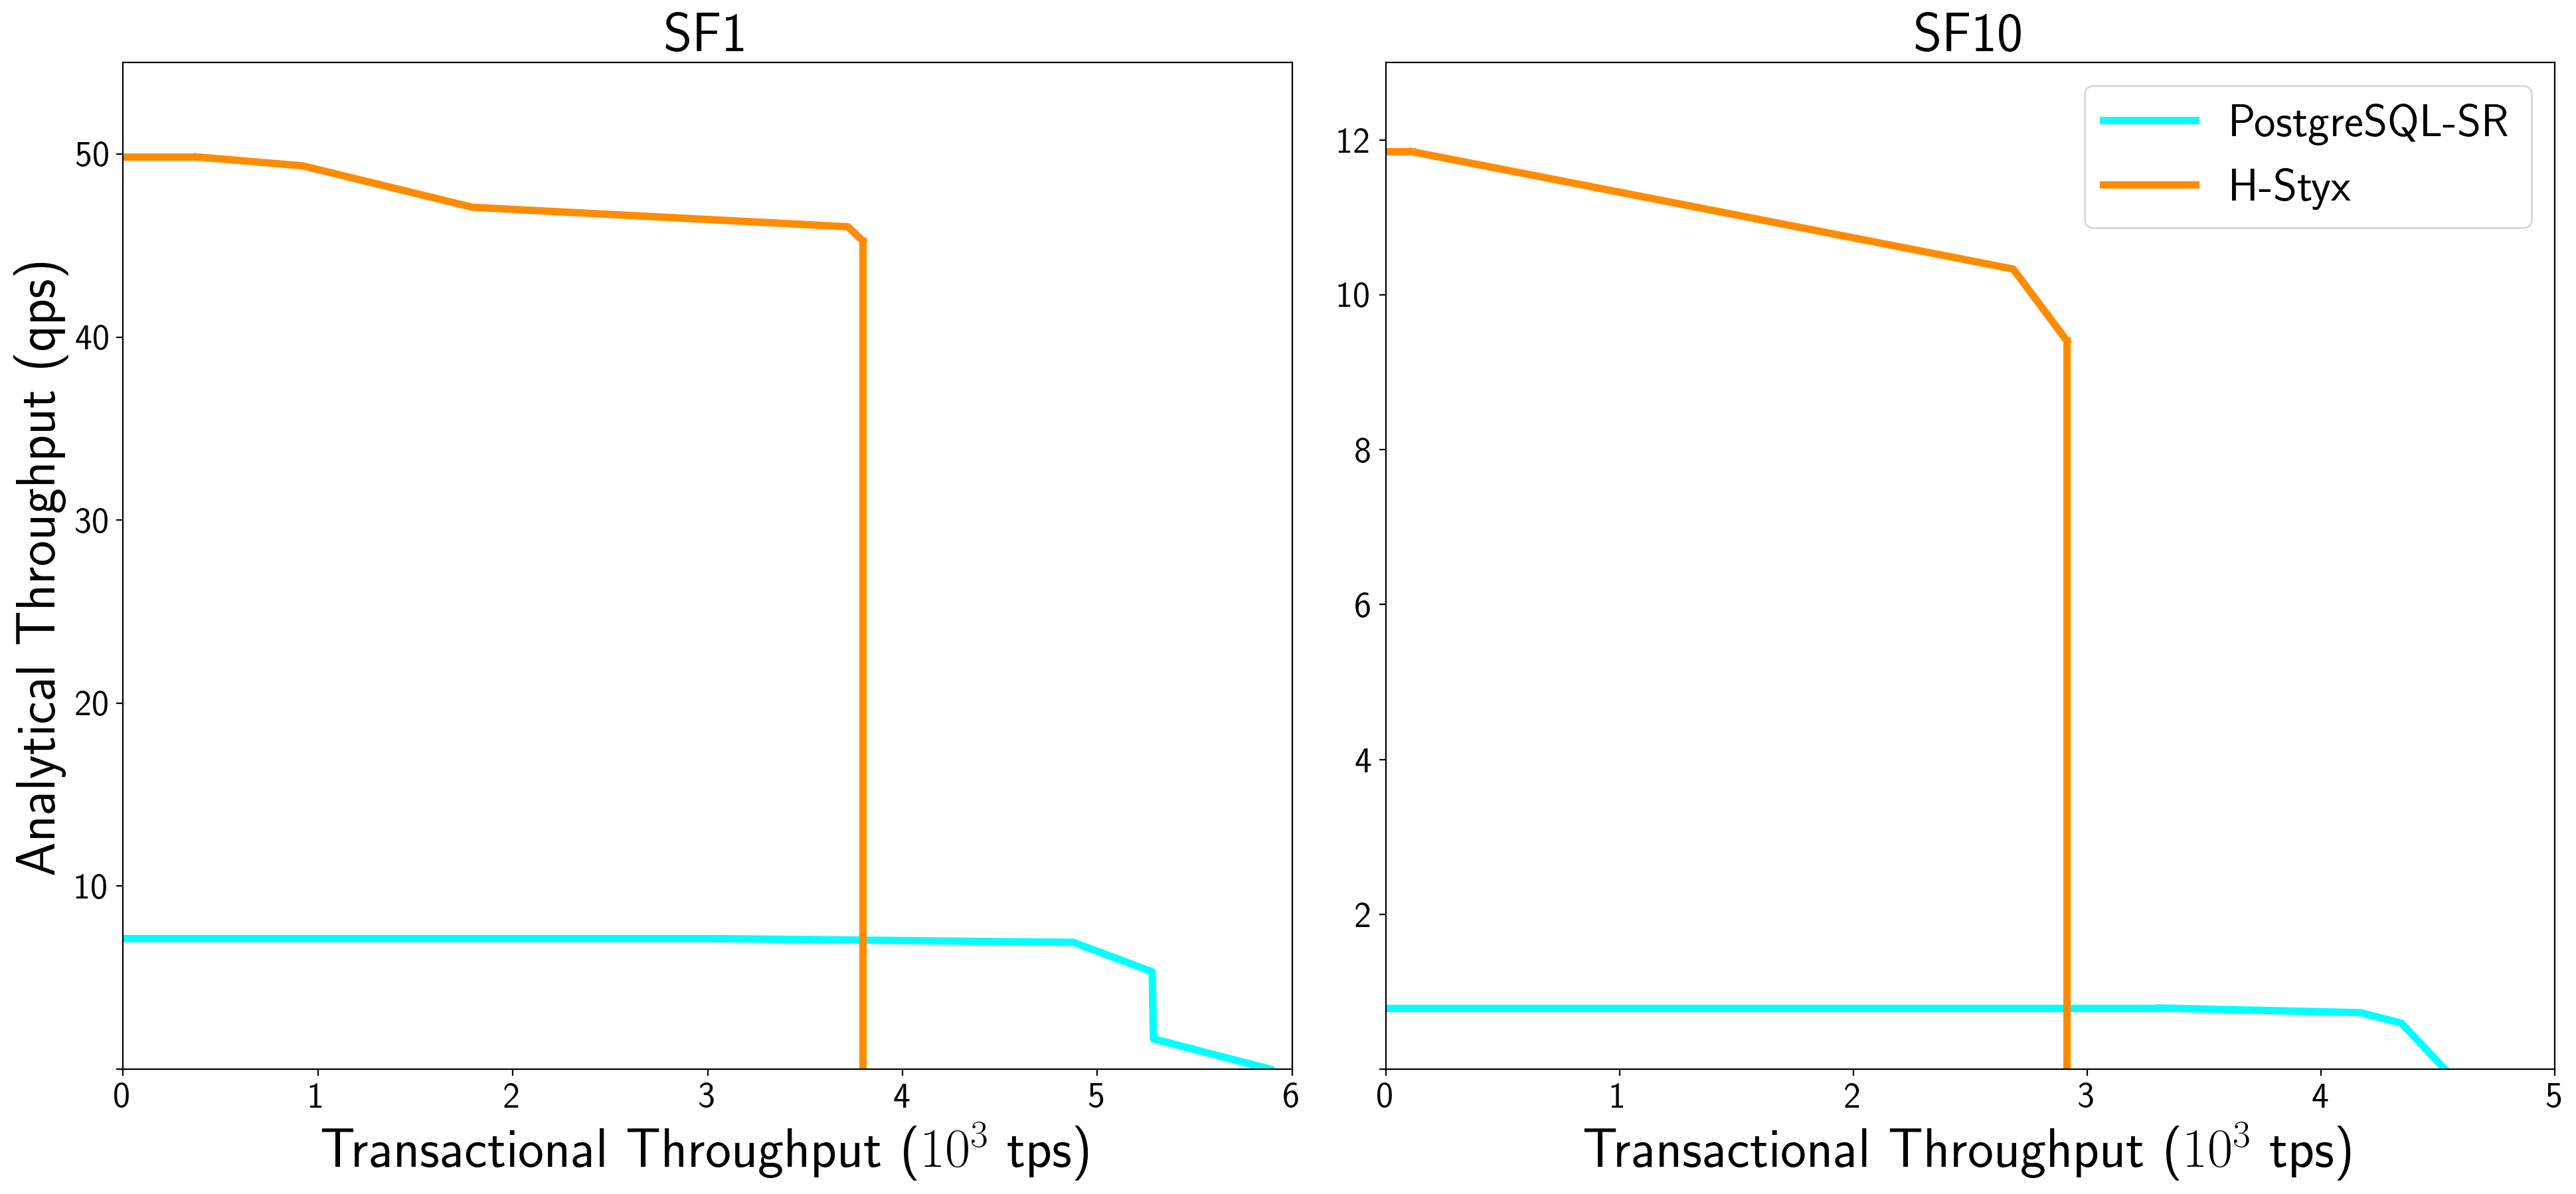

In [10]:
cm = 1/2.54
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(60*cm, 25*cm))
plt.subplots_adjust(wspace=0.08)
plt.rcParams['figure.dpi'] = 200
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['text.usetex'] = True

# ------ SF1 -------
ax1.axis([0, 6000, 0, 55])
x = [0, 1000, 2000, 3000, 4000, 5000, 6000]
xticks = ['0', '1', '2', '3', '4', '5', '6']
ax1.set_xticks(x)
ax1.set_xticklabels(xticks, fontsize=20)
y = [0, 10, 20, 30, 40, 50]
ax1.set_yticks(y, minor=False)
yticks = ['', '10', '20', '30', '40', '50']
ax1.set_yticklabels(yticks, fontsize=20)
ax1.set_title('SF1', fontsize=sub_label_size)

path = "postgres/"
tt_v, ta_v, tt_h, ta_h, district_tc, frontier1, idx1  = preprocess(path+'frontier-SF1.csv')

path = "styx/"
tt_v, ta_v, tt_h, ta_h, district_tc, frontier2, idx2  = preprocess(path+'frontier-SF1.csv')

frontier_plot_basic(frontier1, idx1, ax1, lw=4.0, label='PostgreSQL-SR', color='cyan', hatch=False)
frontier_plot_basic(frontier2, idx2, ax1, lw=4.0, label='H-Styx', color='darkorange', hatch=False)

ax1.set_xlabel('Transactional Throughput ($10^3$ tps)', fontsize=30)
ax1.set_ylabel('Analytical Throughput (qps)', fontsize=30)
plt.rc('grid', linestyle="--", color='#CCCCCC')
plt.grid()


ax2.axis([0, 5000, 0, 13])
x = [0, 1000, 2000, 3000, 4000, 5000]
xticks = ['0', '1', '2', '3', '4', '5']
ax2.set_xticks(x)
ax2.set_xticklabels(xticks, fontsize=20)
y = [0, 2, 4, 6, 8, 10, 12]
yticks = ['', '2', '4', '6', '8', '10', '12']
ax2.set_yticks(y, minor=False)
ax2.set_yticklabels(yticks, fontsize=20)
ax2.set_title('SF10', fontsize=sub_label_size)

path = "postgres/"
tt_v, ta_v, tt_h, ta_h, district_tc, frontier1, idx1  = preprocess(path+'frontier-SF10.csv')

path = "styx/"
tt_v, ta_v, tt_h, ta_h, district_tc, frontier2, idx2  = preprocess(path+'frontier-SF10.csv')

frontier_plot_basic(frontier1, idx1, ax2, lw=4.0, label='PostgreSQL-SR', color='cyan', hatch=False)
frontier_plot_basic(frontier2, idx2, ax2, lw=4.0, label='H-Styx', color='darkorange', hatch=False)

ax2.set_xlabel('Transactional Throughput ($10^3$ tps)', fontsize=30)
plt.rc('grid', linestyle="--", color='#CCCCCC')
plt.legend(loc="upper right", fontsize=25)
plt.grid()
f.savefig('frontier-comparison-plot.png', bbox_inches='tight')

In [18]:
def get_postgres_readings(sf):
    path = "./postgres"
    throughput = pd.read_csv(f'{path}/frontier-SF{sf}.csv', header=None, names=['txn_throughput', 'ana_throughput'])
    ana_latency = pd.read_csv(f'{path}/ana-latency-SF{sf}.csv')
    ana_latency = ana_latency * 1000
    txn_latency = pd.read_csv(f'{path}/txn-latency-SF{sf}.csv')
    txn_latency = txn_latency * 1000
    txn_failures = pd.read_csv(f'{path}/txn-failures-SF{sf}.csv')
    
    ana_tp_lat_pg = pd.concat([throughput[['ana_throughput']], ana_latency], axis=1)
    txn_tp_lat_pg = pd.concat([throughput[['txn_throughput']], txn_latency], axis=1)
    fail_tp_pg = pd.concat([throughput[['txn_throughput']], txn_failures], axis=1)
    
    freshness_files = glob(f"postgres-sf{sf}-latency/freshness-SF{sf}-*.csv")
    freshness_vals = []
    freshness_files.sort()
    for file in freshness_files:
        freshness_df = pd.read_csv(file, header=None)
        expected_freshness = []
        p = freshness_df[0].to_numpy()
        v = freshness_df[1].to_numpy()
        mean_freshness = np.sum(p * v) / 10e6
        total_samples = 10000
        counts = (p * total_samples).astype(int)
        samples = np.repeat(v, counts)
        percentile95_freshness = np.percentile(samples, 95) / 10e6
        max_freshness = np.max(samples) / 10e6
        freshness_vals.append([mean_freshness, percentile95_freshness, max_freshness])
    freshness_df = pd.DataFrame(freshness_vals, columns=['freshness_mean', 'freshness_95p', 'freshness_max'])
    freshness_tp = throughput[throughput['ana_throughput'] != 0].reset_index(drop=True)
    freshness_txn_tp_pg = pd.concat([freshness_tp[['txn_throughput']], freshness_df], axis=1)
    freshness_ana_tp_pg = pd.concat([freshness_tp[['ana_throughput']], freshness_df], axis=1)

    return ana_tp_lat_pg, txn_tp_lat_pg, freshness_txn_tp_pg, freshness_ana_tp_pg, fail_tp_pg

In [19]:
def get_styx_readings(sf):
    files = glob(f"styx-sf{sf}-latency/hattrick/*.json")
    throughputs = {}
    
    for f in files:
        with open(f, "r") as res:
            input_load = tuple([int(x) for x in (os.path.splitext(os.path.basename(f))[0].split(f'SF{sf}_')[1].split('_'))])
            r = json.load(res)
            if 'transactions_processed_per_second' in r and 'queries_processed_per_second' in r:
                throughputs[input_load] = [r['transactional_throughput']['avg'], r['analytical_throughput']['avg'], 
                                           r['transactional latency (ms)']['mean'], r['transactional latency (ms)']['95'], r['transactional latency (ms)']['99'],
                                           r['analytical latency (ms)']['mean'], r['analytical latency (ms)']['95'], r['analytical latency (ms)']['99']]
            elif 'queries_processed_per_second' in r:
                throughputs[input_load] = [0, r['analytical_throughput']['avg'], 
                                           0, 0, 0, 
                                           r['analytical latency (ms)']['mean'], r['analytical latency (ms)']['95'], r['analytical latency (ms)']['99']]
            elif 'transactions_processed_per_second' in r:
                throughputs[input_load] = [r['transactional_throughput']['avg'], 0, 
                                           r['transactional latency (ms)']['mean'], r['transactional latency (ms)']['95'], r['transactional latency (ms)']['99'],
                                           0, 0, 0]
            else:
                throughputs[input_load] = [0, 0, 0, 0, 0, 0, 0, 0]
    
            if 'freshness (ms)' in r:
                throughputs[input_load].extend([r['freshness (ms)']['mean'], r['freshness (ms)']['95'], r['freshness (ms)']['max']])
            else:
                throughputs[input_load].extend([0, 0, 0])
    
            
    cols = ["txn_throughput", "ana_throughput", 
            "txn_mean_latency", "txn_95p_latency", "txn_99p_latency", 
            "ana_mean_latency", "ana_95p_latency", "ana_99p_latency",
            "freshness_mean", "freshness_95p", "freshness_max"
           ]
    sorted_items = sorted(throughputs.items())
    values = [v for k, v in sorted_items]
    styx_metrics = pd.DataFrame(values, columns=cols)
    
    ana_tp_lat_styx = styx_metrics[['ana_throughput', 'ana_mean_latency', 'ana_95p_latency', 'ana_99p_latency']]
    txn_tp_lat_styx = styx_metrics[['txn_throughput', 'txn_mean_latency', 'txn_95p_latency', 'txn_99p_latency']]
    freshness_txn_tp_styx = styx_metrics[['txn_throughput', 'freshness_mean', 'freshness_95p', 'freshness_max']]
    freshness_ana_tp_styx = styx_metrics[['ana_throughput', 'freshness_mean', 'freshness_95p', 'freshness_max']]

    return ana_tp_lat_styx, txn_tp_lat_styx, freshness_txn_tp_styx, freshness_ana_tp_styx

In [20]:
colors1 = ['#17becf', '#33cccc', '#66e0e0']
colors2 = ["#ff7f0e", "#ff9933", "#ffcc66"]
colors = ['lightblue', 'lightgreen', 'pink']

ana_latency_cols = ['ana_mean_latency', 'ana_95p_latency', 'ana_99p_latency']
ana_latency_labels = ['Mean Latency', '95p Latency', '99p Latency']

txn_latency_cols = ['txn_mean_latency', 'txn_95p_latency', 'txn_99p_latency']
txn_latency_labels = ['Mean Latency', '95p Latency', '99p Latency']

freshness_cols = ['freshness_mean', 'freshness_95p', 'freshness_max']
freshness_labels = ['Mean Freshness', '95p Freshness', 'Max Freshness']

failure_cols = ['Percentage', 'Total with retries']

def sort_and_monotonic(df, sort_column, latency_cols):
    df_sorted = df.sort_values(by=sort_column).reset_index(drop=True)
    for col in latency_cols:
        df_sorted[col] = df_sorted[col].cummax()
    return df_sorted

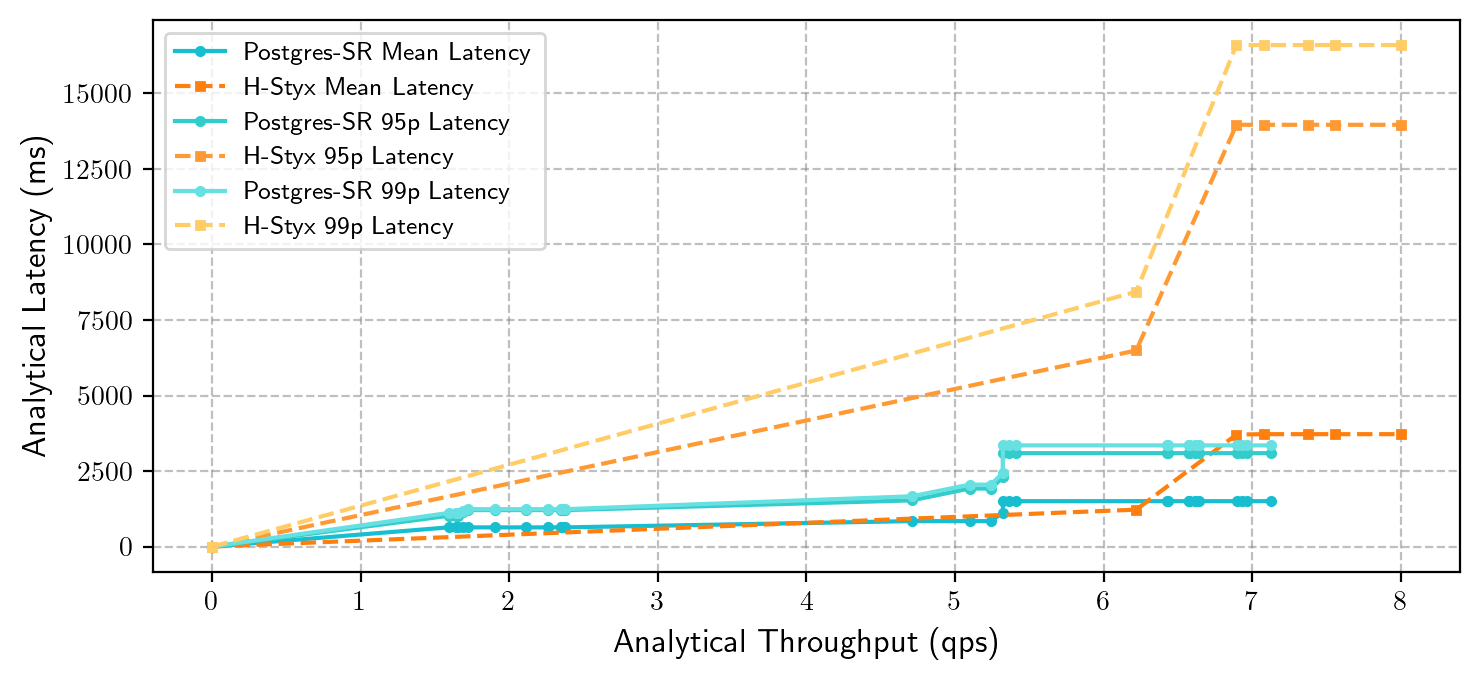

In [21]:
ana_tp_lat_pg, txn_tp_lat_pg, freshness_txn_tp_pg, freshness_ana_tp_pg, fail_tp_pg = get_postgres_readings(1)
ana_tp_lat_styx, txn_tp_lat_styx, freshness_txn_tp_styx, freshness_ana_tp_styx = get_styx_readings(1)
ana_tp_lat_styx_comp = ana_tp_lat_styx[ana_tp_lat_styx['ana_throughput'] <= 8]

df1_sorted = sort_and_monotonic(ana_tp_lat_pg, 'ana_throughput', ana_latency_cols)
df2_sorted = sort_and_monotonic(ana_tp_lat_styx_comp, 'ana_throughput', ana_latency_cols)

for i, col in enumerate(ana_latency_cols):
    plt.plot(df1_sorted['ana_throughput'], df1_sorted[col], 
             color=colors1[i], marker='o', markersize=3, linestyle='-', 
             label=f"Postgres-SR {ana_latency_labels[i]}")
    plt.plot(df2_sorted['ana_throughput'], df2_sorted[col], 
             color=colors2[i], marker='s', markersize=3, linestyle='--', 
             label=f"H-Styx {ana_latency_labels[i]}")

plt.xlabel("Analytical Throughput (qps)", fontsize=12)
plt.ylabel("Analytical Latency (ms)", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', color='gray', alpha=0.5)
plt.tight_layout()
plt.savefig('ana_throughput_v_latency_comp_SF1.png', dpi=300, bbox_inches='tight')
plt.show()

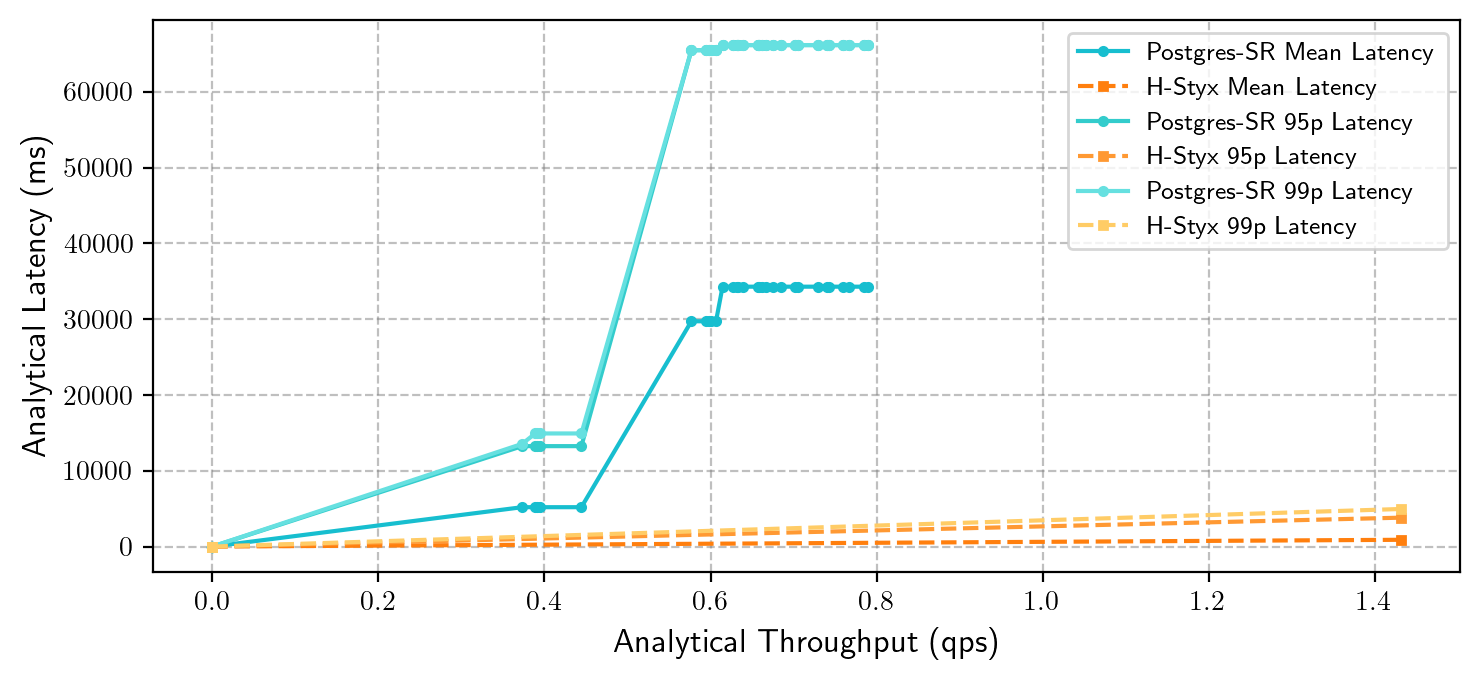

In [22]:
ana_tp_lat_pg, txn_tp_lat_pg, freshness_txn_tp_pg, freshness_ana_tp_pg, fail_tp_pg = get_postgres_readings(10)
ana_tp_lat_styx, txn_tp_lat_styx, freshness_txn_tp_styx, freshness_ana_tp_styx = get_styx_readings(10)
ana_tp_lat_styx_comp = ana_tp_lat_styx[ana_tp_lat_styx['ana_throughput'] <= 1.5]

df1_sorted = sort_and_monotonic(ana_tp_lat_pg, 'ana_throughput', ana_latency_cols)
df2_sorted = sort_and_monotonic(ana_tp_lat_styx_comp, 'ana_throughput', ana_latency_cols)

for i, col in enumerate(ana_latency_cols):
    plt.plot(df1_sorted['ana_throughput'], df1_sorted[col], 
             color=colors1[i], marker='o', markersize=3, linestyle='-', 
             label=f"Postgres-SR {ana_latency_labels[i]}")
    plt.plot(df2_sorted['ana_throughput'], df2_sorted[col], 
             color=colors2[i], marker='s', markersize=3, linestyle='--', 
             label=f"H-Styx {ana_latency_labels[i]}")
plt.xlabel("Analytical Throughput (qps)", fontsize=12)
plt.ylabel("Analytical Latency (ms)", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', color='gray', alpha=0.5)
plt.tight_layout()
plt.savefig('ana_throughput_v_latency_comp_SF10.png', dpi=300, bbox_inches='tight')
plt.show()

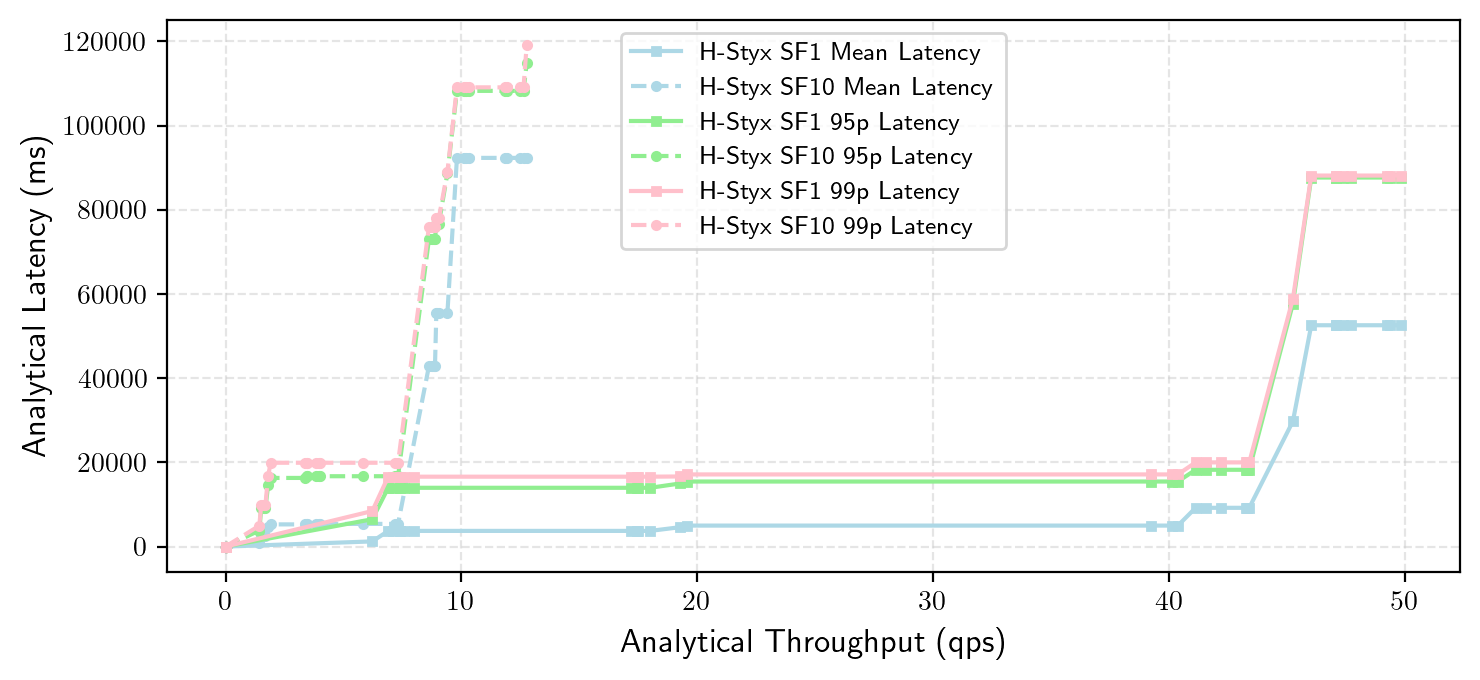

In [23]:
ana_tp_lat_styx1, txn_tp_lat_styx, freshness_txn_tp_styx, freshness_ana_tp_styx = get_styx_readings(1)
ana_tp_lat_styx10, txn_tp_lat_styx, freshness_txn_tp_styx, freshness_ana_tp_styx = get_styx_readings(10)

df1_sorted = sort_and_monotonic(ana_tp_lat_styx1, 'ana_throughput', ana_latency_cols)
df2_sorted = sort_and_monotonic(ana_tp_lat_styx10, 'ana_throughput', ana_latency_cols)

for i, col in enumerate(ana_latency_cols):
    plt.plot(df1_sorted['ana_throughput'], df1_sorted[col], 
             color=colors[i], marker='s', markersize=3, linestyle='-', 
             label=f"H-Styx SF1 {ana_latency_labels[i]}")
    plt.plot(df2_sorted['ana_throughput'], df2_sorted[col], 
             color=colors[i], marker='o', markersize=3, linestyle='--', 
             label=f"H-Styx SF10 {ana_latency_labels[i]}")

plt.xlabel("Analytical Throughput (qps)", fontsize=12)
plt.ylabel("Analytical Latency (ms)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('ana_throughput_v_latency_hstyx.png', dpi=300, bbox_inches='tight')
plt.show()

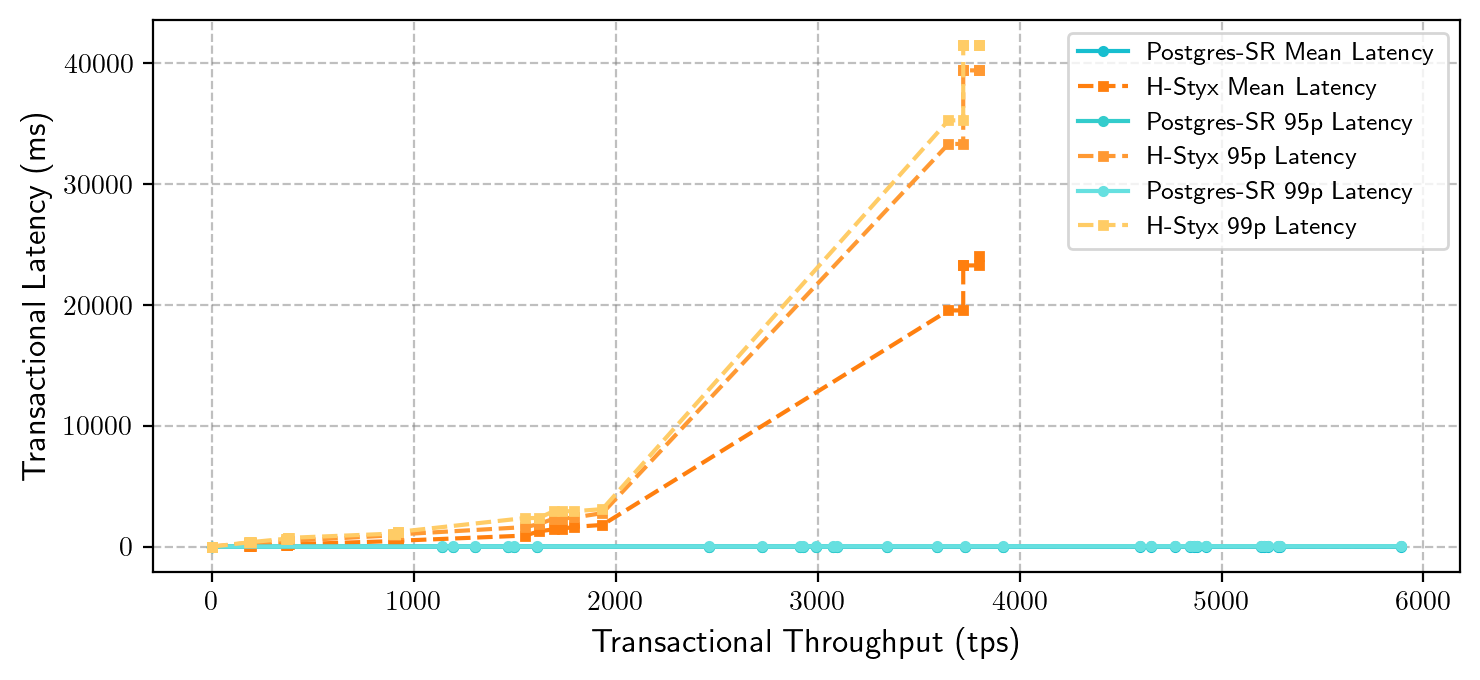

In [24]:
ana_tp_lat_pg, txn_tp_lat_pg, freshness_txn_tp_pg, freshness_ana_tp_pg, fail_tp_pg = get_postgres_readings(1)
ana_tp_lat_styx, txn_tp_lat_styx, freshness_txn_tp_styx, freshness_ana_tp_styx = get_styx_readings(1)

df1_sorted = sort_and_monotonic(txn_tp_lat_pg, 'txn_throughput', txn_latency_cols)
df2_sorted = sort_and_monotonic(txn_tp_lat_styx, 'txn_throughput', txn_latency_cols)

for i, col in enumerate(txn_latency_cols):
    plt.plot(df1_sorted['txn_throughput'], df1_sorted[col], 
             color=colors1[i], marker='o', markersize=3, linestyle='-', 
             label=f"Postgres-SR {txn_latency_labels[i]}")
    plt.plot(df2_sorted['txn_throughput'], df2_sorted[col], 
             color=colors2[i], marker='s', markersize=3, linestyle='--', 
             label=f"H-Styx {txn_latency_labels[i]}")
plt.xlabel("Transactional Throughput (tps)", fontsize=12)
plt.ylabel("Transactional Latency (ms)", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', color='gray', alpha=0.5)
plt.tight_layout()
plt.savefig('txn_throughput_v_latency_comp_SF1.png', dpi=300, bbox_inches='tight')
plt.show()

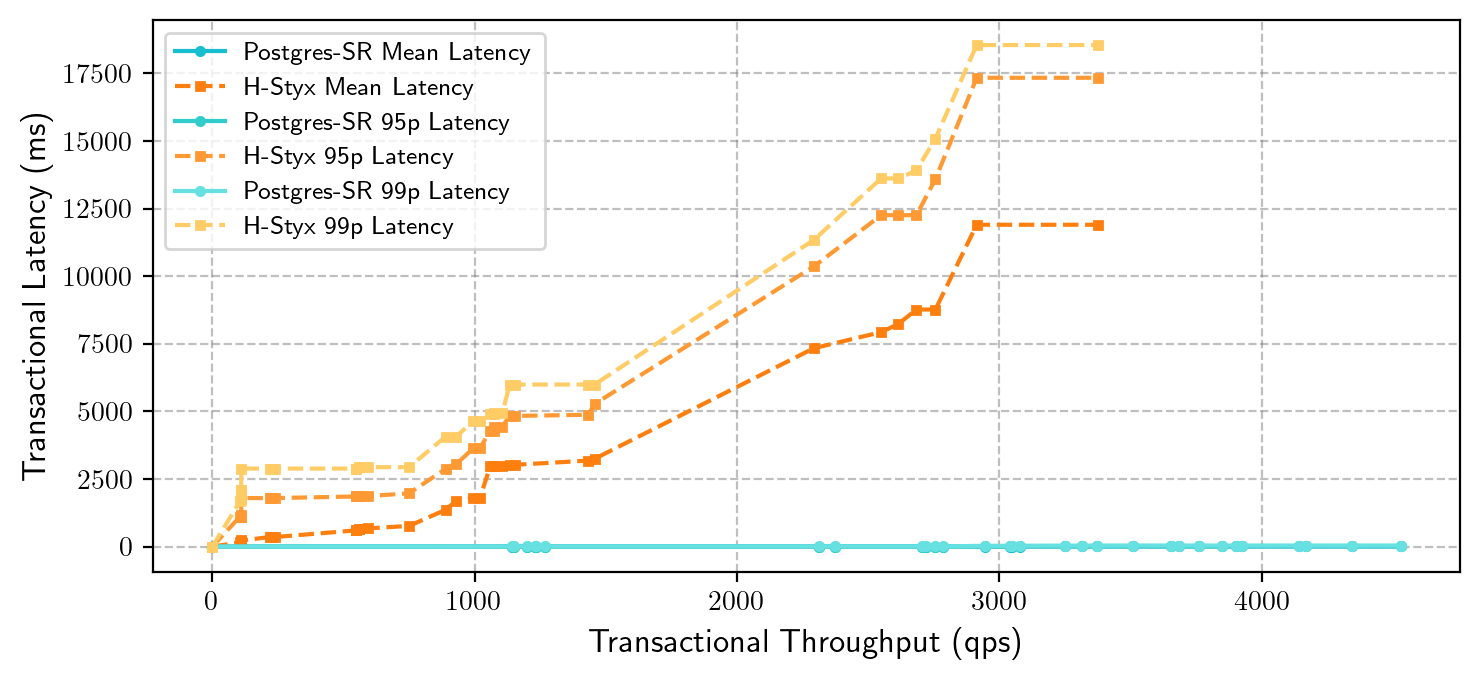

In [25]:
ana_tp_lat_pg, txn_tp_lat_pg, freshness_txn_tp_pg, freshness_ana_tp_pg, fail_tp_pg = get_postgres_readings(10)
ana_tp_lat_styx, txn_tp_lat_styx, freshness_txn_tp_styx, freshness_ana_tp_styx = get_styx_readings(10)

df1_sorted = sort_and_monotonic(txn_tp_lat_pg, 'txn_throughput', txn_latency_cols)
df2_sorted = sort_and_monotonic(txn_tp_lat_styx, 'txn_throughput', txn_latency_cols)

for i, col in enumerate(txn_latency_cols):
    plt.plot(df1_sorted['txn_throughput'], df1_sorted[col], 
             color=colors1[i], marker='o', markersize=3, linestyle='-', 
             label=f"Postgres-SR {txn_latency_labels[i]}")
    plt.plot(df2_sorted['txn_throughput'], df2_sorted[col], 
             color=colors2[i], marker='s', markersize=3, linestyle='--', 
             label=f"H-Styx {txn_latency_labels[i]}")
plt.xlabel("Transactional Throughput (qps)", fontsize=12)
plt.ylabel("Transactional Latency (ms)", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', color='gray', alpha=0.5)
plt.tight_layout()
plt.savefig('txn_throughput_v_latency_comp_SF10.png', dpi=300, bbox_inches='tight')
plt.show()

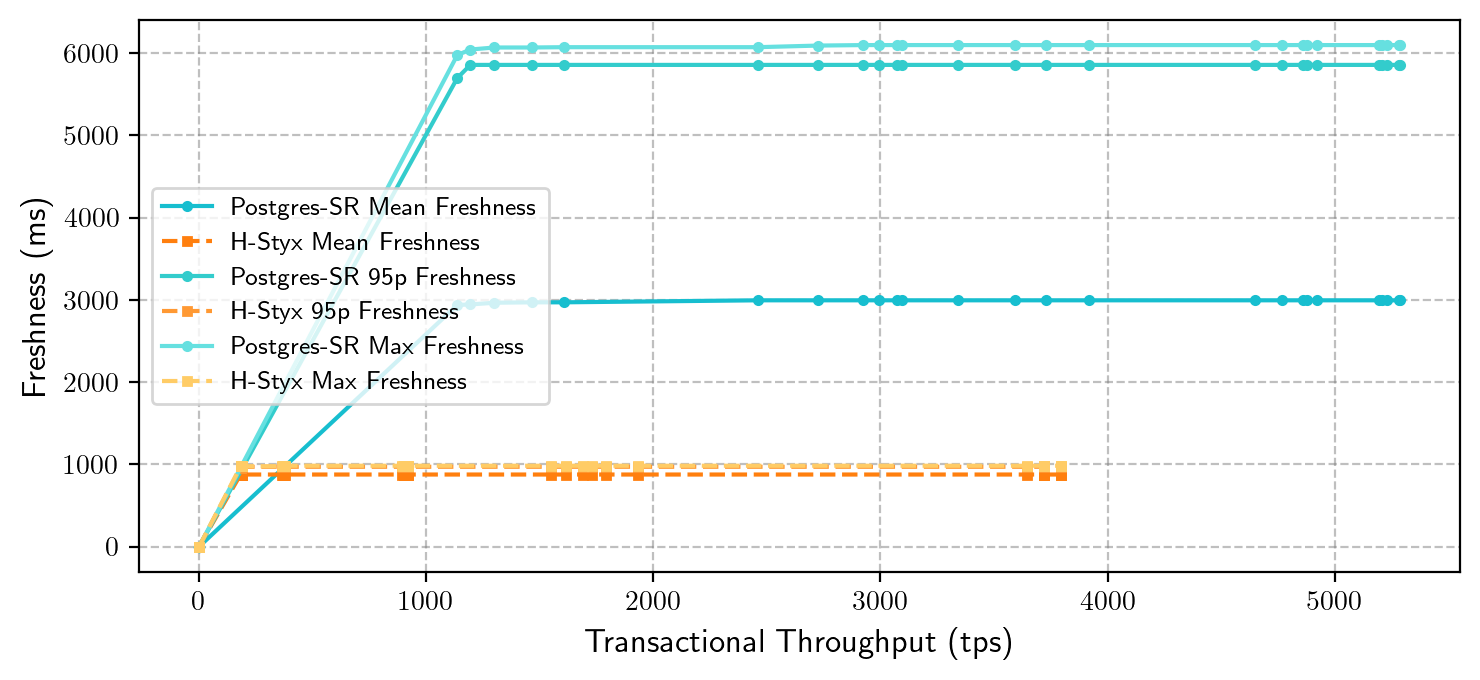

In [26]:
ana_tp_lat_pg, txn_tp_lat_pg, freshness_txn_tp_pg, freshness_ana_tp_pg, fail_tp_pg = get_postgres_readings(1)
ana_tp_lat_styx, txn_tp_lat_styx, freshness_txn_tp_styx, freshness_ana_tp_styx = get_styx_readings(1)

df1_sorted = sort_and_monotonic(freshness_txn_tp_pg, 'txn_throughput', freshness_cols)
df2_sorted = sort_and_monotonic(freshness_txn_tp_styx, 'txn_throughput', freshness_cols)

for i, col in enumerate(freshness_cols):
    plt.plot(df1_sorted['txn_throughput'], df1_sorted[col], 
             color=colors1[i], marker='o', markersize=3, linestyle='-', 
             label=f"Postgres-SR {freshness_labels[i]}")
    plt.plot(df2_sorted['txn_throughput'], df2_sorted[col], 
             color=colors2[i], marker='s', markersize=3, linestyle='--', 
             label=f"H-Styx {freshness_labels[i]}")
plt.xlabel("Transactional Throughput (tps)", fontsize=12)
plt.ylabel("Freshness (ms)", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', color='gray', alpha=0.5)
plt.tight_layout()
plt.savefig('txn_throughput_v_freshness_comp_SF1.png', dpi=300, bbox_inches='tight')
plt.show()

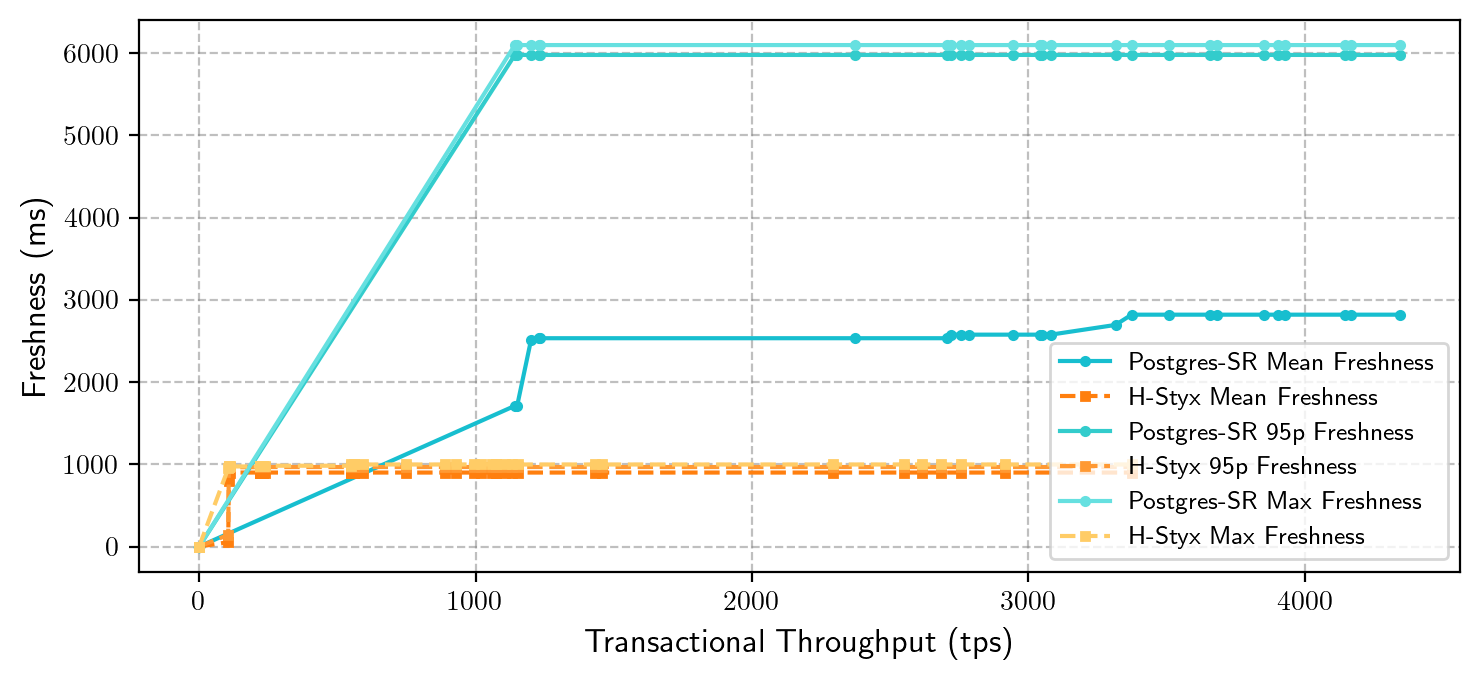

In [27]:
ana_tp_lat_pg, txn_tp_lat_pg, freshness_txn_tp_pg, freshness_ana_tp_pg, fail_tp_pg = get_postgres_readings(10)
ana_tp_lat_styx, txn_tp_lat_styx, freshness_txn_tp_styx, freshness_ana_tp_styx = get_styx_readings(10)

df1_sorted = sort_and_monotonic(freshness_txn_tp_pg, 'txn_throughput', freshness_cols)
df2_sorted = sort_and_monotonic(freshness_txn_tp_styx, 'txn_throughput', freshness_cols)

for i, col in enumerate(freshness_cols):
    plt.plot(df1_sorted['txn_throughput'], df1_sorted[col], 
             color=colors1[i], marker='o', markersize=3, linestyle='-', 
             label=f"Postgres-SR {freshness_labels[i]}")
    plt.plot(df2_sorted['txn_throughput'], df2_sorted[col], 
             color=colors2[i], marker='s', markersize=3, linestyle='--', 
             label=f"H-Styx {freshness_labels[i]}")
plt.xlabel("Transactional Throughput (tps)", fontsize=12)
plt.ylabel("Freshness (ms)", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', color='gray', alpha=0.5)
plt.tight_layout()
plt.savefig('txn_throughput_v_freshness_comp_SF10.png', dpi=300, bbox_inches='tight')
plt.show()

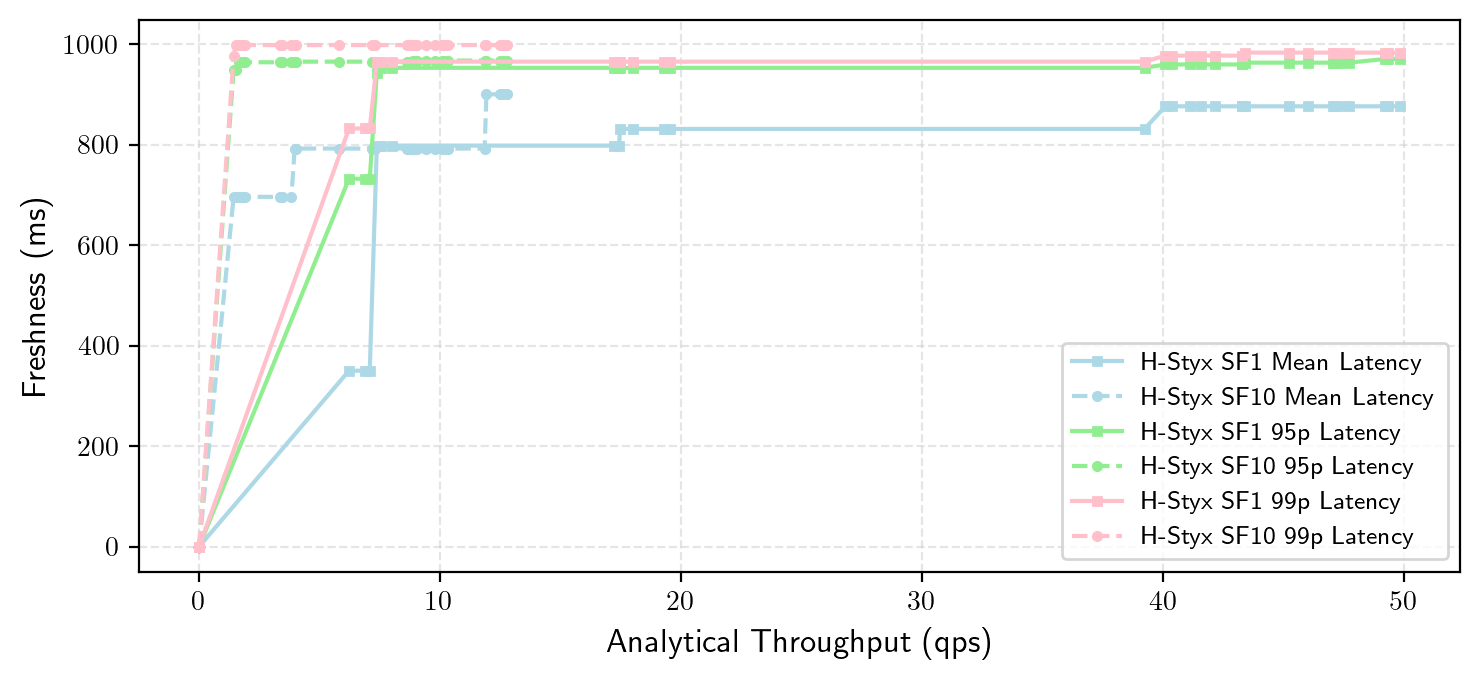

In [28]:
ana_tp_lat_styx, txn_tp_lat_styx, freshness_txn_tp_styx, freshness_ana_tp_styx1 = get_styx_readings(1)
ana_tp_lat_styx, txn_tp_lat_styx, freshness_txn_tp_styx, freshness_ana_tp_styx10 = get_styx_readings(10)

df1_sorted = sort_and_monotonic(freshness_ana_tp_styx1, 'ana_throughput', freshness_cols)
df2_sorted = sort_and_monotonic(freshness_ana_tp_styx10, 'ana_throughput', freshness_cols)

for i, col in enumerate(freshness_cols):
    plt.plot(df1_sorted['ana_throughput'], df1_sorted[col], 
             color=colors[i], marker='s', markersize=3, linestyle='-', 
             label=f"H-Styx SF1 {ana_latency_labels[i]}")
    plt.plot(df2_sorted['ana_throughput'], df2_sorted[col], 
             color=colors[i], marker='o', markersize=3, linestyle='--', 
             label=f"H-Styx SF10 {ana_latency_labels[i]}")

plt.xlabel("Analytical Throughput (qps)", fontsize=12)
plt.ylabel("Freshness (ms)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('ana_throughput_v_freshness_hstyx.png', dpi=300, bbox_inches='tight')
plt.show()

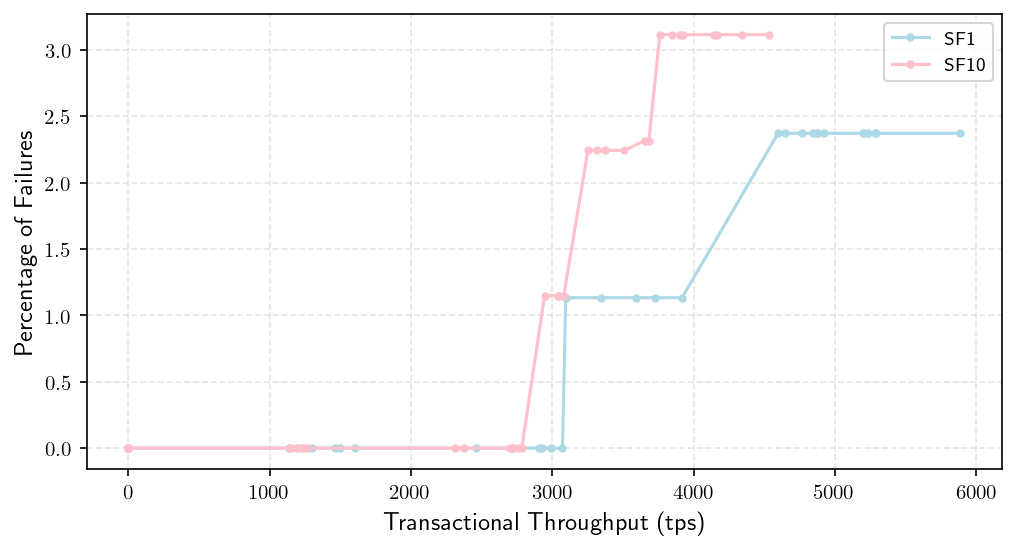

In [29]:
ana_tp_lat_pg, txn_tp_lat_pg, freshness_txn_tp_pg, freshness_ana_tp_pg, fail_tp_pg1 = get_postgres_readings(1)
ana_tp_lat_pg, txn_tp_lat_pg, freshness_txn_tp_pg, freshness_ana_tp_pg, fail_tp_pg10 = get_postgres_readings(10)

cm = 1/2.54
fig, ax1 = plt.subplots(1, figsize=(20*cm, 10*cm), dpi=150)

fail_tp_pg1 = sort_and_monotonic(fail_tp_pg1, 'txn_throughput', failure_cols)
fail_tp_pg10 = sort_and_monotonic(fail_tp_pg10, 'txn_throughput', failure_cols)
ax1.plot(fail_tp_pg1['txn_throughput'], fail_tp_pg1['Percentage'], 
             color=colors[0], marker='o', markersize=3, linestyle='-', 
             label=f"SF1")
ax1.plot(fail_tp_pg10['txn_throughput'], fail_tp_pg10['Percentage'], 
             color=colors[2], marker='o', markersize=3, linestyle='-', 
             label=f"SF10")

ax1.set_xlabel("Transactional Throughput (tps)", fontsize=12)
ax1.set_ylabel("Percentage of Failures", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=9)

plt.savefig('txn_throughput_v_fails_pg.png', dpi=300, bbox_inches='tight')
plt.show()